# Predictive Analytics: Neural Network - Advanced Baseline v6

=> based on advanced baseline v5, select best model based on weighted criteria

In [1]:
import polars as pl
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from pathlib import Path
import math
import matplotlib.pyplot as plt

from run_config import MODELS_DIR, PATHS

from helper_functions import (
    get_torch_device,
    load_model_from_checkpoint,
    collect_predictions,
    compute_regression_metrics,
    plot_regression_diagnostics,
)

## Preparations

In [2]:
# "Settings" / Decisions for the training data

SPATIAL_UNIT = "community_areas"
TIME_UNIT = "4h"
DATASET_STEM = f"GOLD_{TIME_UNIT.upper()}_DEMAND_{SPATIAL_UNIT.upper()}"
MODEL_TAG = f"{SPATIAL_UNIT}_{TIME_UNIT}"
TRAINING_DATA_PATH = PATHS.train_test_dir / f"{DATASET_STEM}_TRAIN.parquet"
VAL_DATA_PATH = PATHS.train_test_dir / f"{DATASET_STEM}_VAL.parquet"
MODEL_PATH = MODELS_DIR
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Target and feature selection
TARGET_COL = "trip_count"
COMMUNITY_COL = "community_area"
EXCLUDE_COLS = [
    TARGET_COL,
    "datetime_hour",      # real timestamp would lead to much leakage
    "date",
    "_split_bucket",      # only used for splitting
    "month", # cyclic feature is used instead
    "weekday", # cyclic feature is used instead
    "hour", # cyclic feature is used instead
    # all other taxi data columns must be excluded to prevent leakage
    "trip_seconds_sum",
    "trip_seconds_mean",
    "trip_seconds_min",
    "trip_seconds_max",
    "trip_miles_sum",
    "trip_miles_mean",
    "trip_miles_min",
    "trip_miles_max",
    "fare_sum",
    "fare_mean",
    "fare_min",
    "fare_max",
    "tips_sum",
    "tips_mean",
    "tips_min",
    "tips_max",
    "tolls_sum",
    "tolls_mean",
    "tolls_min",
    "tolls_max",
    "extras_sum",
    "extras_mean",
    "extras_min",
    "extras_max",
    "trip_total_sum",
    "trip_total_mean",
    "trip_total_min",
    "trip_total_max",
    "most_common_payment_type",
]

        

### Load the data and select features and target

In [3]:
# Load the tranining data
train_df = pl.scan_parquet(TRAINING_DATA_PATH)
val_df = pl.scan_parquet(VAL_DATA_PATH)

numeric_feature_cols = [
    col for col in train_df.collect_schema().names()
    if col not in EXCLUDE_COLS
    and col != COMMUNITY_COL
]

X_train_numeric = train_df.select(numeric_feature_cols).collect()
X_val_numeric = val_df.select(numeric_feature_cols).collect()

community_train_raw = (
    train_df.select(COMMUNITY_COL)
    .collect()
    .to_series()
    .to_numpy()
)

community_val_raw = (
    val_df.select(COMMUNITY_COL)
    .collect()
    .to_series()
    .to_numpy()
)

y_train = train_df.select(TARGET_COL).collect()
y_val = val_df.select(TARGET_COL).collect()

In [4]:
# Embedding
known_communities = sorted(np.unique(community_train_raw))

community_to_idx = {
    community_id: idx + 1
    for idx, community_id in enumerate(known_communities)
}

UNKNOWN_COMMUNITY_IDX = 0

community_train_idx = np.array(
    [community_to_idx.get(x, UNKNOWN_COMMUNITY_IDX)
     for x in community_train_raw],
    dtype=np.int64
)

community_val_idx = np.array(
    [community_to_idx.get(x, UNKNOWN_COMMUNITY_IDX)
     for x in community_val_raw],
    dtype=np.int64
)

num_communities = len(community_to_idx) + 1

print("Anzahl Embedding-Kategorien:", num_communities)

Anzahl Embedding-Kategorien: 78


Impotant, check datatype of features and target. Everything should be numerical. We already applied encoding to categorical features (e. g. cloud coverage), therefore all features are numerical.

In [5]:
def make_sample_weights(y_original):
    y = np.asarray(y_original).reshape(-1)

    weights = np.ones_like(y, dtype=np.float32)

    weights[(y > 0) & (y <= 2)] = 1.2
    weights[(y > 2) & (y <= 10)] = 1.5
    weights[(y > 10) & (y <= 20)] = 3.0
    weights[y > 20] = 5.0

    return weights

train_weights_np = make_sample_weights(y_train)

### Scale the train data

Important, the scaler is only fitted on X_train to prevent data leakage

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_numeric.to_numpy()
).astype("float32")

X_val_scaled = scaler.transform(
    X_val_numeric.to_numpy()
).astype("float32")

y_train_np = np.log1p(
    y_train.to_numpy()
).astype("float32")

y_val_np = np.log1p(
    y_val.to_numpy()
).astype("float32")

### PyTorch Dataset and DataLoader

In [7]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)

community_train_tensor = torch.tensor(
    community_train_idx,
    dtype=torch.long
)

community_val_tensor = torch.tensor(
    community_val_idx,
    dtype=torch.long
)

y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_np, dtype=torch.float32)

train_weights_tensor = torch.tensor(
    train_weights_np,
    dtype=torch.float32
)

train_dataset = TensorDataset(
    X_train_tensor,
    community_train_tensor,
    y_train_tensor,
    train_weights_tensor,
)

val_dataset = TensorDataset(
    X_val_tensor,
    community_val_tensor,
    y_val_tensor,
)

**BATCH_SIZE** we start with a standard batch_size of 1024 as we have a lot of training data and a smaller batch_size would lead to too many updates in each epoche

Possible, other used batch_sizes could be: 32, 64, 128, 256, 512, 1024, 2048

In [8]:
# Create the data loader
BATCH_SIZE = 1024

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Test
X_batch, community_batch, y_batch, weight_batch = next(iter(train_loader))

print("Numerische Features:", X_batch.shape)
print("Community IDs:", community_batch.shape)
print("Target:", y_batch.shape)
print("Gewichte:", weight_batch.shape)

Numerische Features: torch.Size([1024, 22])
Community IDs: torch.Size([1024])
Target: torch.Size([1024, 1])
Gewichte: torch.Size([1024])


## Advanced Baseline v5

In [9]:
# model needs the number of features
input_dim = X_train_tensor.shape[1]

print("Input Features:", input_dim)

Input Features: 22


### Model architecture


In [10]:
class TaxiDemandAdvancedNN(nn.Module):
    def __init__(
        self,
        numeric_input_dim,
        num_communities,
        embedding_dim=8,
    ):
        super().__init__()

        self.community_embedding = nn.Embedding(
            num_embeddings=num_communities,
            embedding_dim=embedding_dim,
            padding_idx=0,
        )

        combined_input_dim = numeric_input_dim + embedding_dim

        self.network = nn.Sequential(
            nn.Linear(combined_input_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),
        )

    def forward(self, x_numeric, community_idx):
        community_embedding = self.community_embedding(community_idx)

        combined = torch.cat(
            [x_numeric, community_embedding],
            dim=1,
        )

        return self.network(combined)

In [11]:
# initialise model
numeric_input_dim = X_train_tensor.shape[1]
embedding_dim = 8

model = TaxiDemandAdvancedNN(
    numeric_input_dim=numeric_input_dim,
    num_communities=num_communities,
    embedding_dim=embedding_dim,
)

In [12]:
# Test with one batch
X_batch, community_batch, y_batch, weight_batch = next(iter(train_loader))

y_pred = model(X_batch, community_batch)

print("Numeric input:", X_batch.shape)
print("Community input:", community_batch.shape)
print("Prediction:", y_pred.shape)
print("Target:", y_batch.shape)

Numeric input: torch.Size([1024, 22])
Community input: torch.Size([1024])
Prediction: torch.Size([1024, 1])
Target: torch.Size([1024, 1])


There it important to check that the shape is the batch_size and the right dimension, i. e. number of features / target

In [13]:
device = get_torch_device()

print("Using device:", device)
model = model.to(device)

Using device: mps


### Loss function and optimizer

As loss we start with MSELoss, which means that larger errors are larger penalized. And we use ADAM as optimizer with a learning rate of 0.001 as of now.

Options for further models:
- L1Loss(): more similar to MAE

In [14]:
criterion = nn.L1Loss(
    reduction="none",
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

### Trainingsloop and Validation

In [15]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    
    total_loss = 0.0
    total_samples = 0
    
    for X_batch, community_batch, y_batch, weight_batch in train_loader:
        X_batch = X_batch.to(device)
        community_batch = community_batch.to(device)
        y_batch = y_batch.to(device)
        weight_batch = weight_batch.to(device)

        optimizer.zero_grad()

        y_pred = model(X_batch, community_batch)
        y_batch = y_batch.view_as(y_pred)

        individual_losses = criterion(y_pred, y_batch)

        loss = (
            individual_losses.reshape(-1)
            * weight_batch.reshape(-1)
        ).mean()

        loss.backward()
        optimizer.step()
        
        batch_size = X_batch.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size
    
    avg_loss = total_loss / total_samples
    return avg_loss

def evaluate(
    model,
    val_loader,
    criterion,
    device,
    high_demand_threshold=20,
):
    model.eval()

    total_loss = 0.0
    total_absolute_error = 0.0
    total_squared_error = 0.0
    total_samples = 0

    y_true_parts = []
    y_pred_parts = []

    with torch.no_grad():
        for X_batch, community_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            community_batch = community_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch, community_batch)
            y_batch = y_batch.view_as(y_pred)

            # L1Loss auf log1p-Skala
            loss = criterion(y_pred, y_batch).mean()

            # Rücktransformation auf trip_count-Skala
            y_pred_original = torch.expm1(y_pred)
            y_true_original = torch.expm1(y_batch)

            y_pred_original = torch.clamp(
                y_pred_original,
                min=0,
            )

            batch_size = X_batch.size(0)

            total_loss += loss.item() * batch_size
            total_absolute_error += torch.sum(
                torch.abs(y_pred_original - y_true_original)
            ).item()
            total_squared_error += torch.sum(
                (y_pred_original - y_true_original) ** 2
            ).item()
            total_samples += batch_size

            y_true_parts.append(
                y_true_original.cpu().numpy().reshape(-1)
            )
            y_pred_parts.append(
                y_pred_original.cpu().numpy().reshape(-1)
            )

    val_log_mae = total_loss / total_samples
    val_mae = total_absolute_error / total_samples
    val_rmse = (total_squared_error / total_samples) ** 0.5

    y_true = np.concatenate(y_true_parts)
    y_pred = np.concatenate(y_pred_parts)

    high_demand_mask = y_true > high_demand_threshold

    if high_demand_mask.any():
        high_demand_errors = np.abs(
            y_true[high_demand_mask]
            - y_pred[high_demand_mask]
        )

        high_demand_mae = high_demand_errors.mean()
        high_demand_median_ae = np.median(
            high_demand_errors
        )
    else:
        high_demand_mae = np.nan
        high_demand_median_ae = np.nan

    return (
        val_log_mae,
        val_mae,
        val_rmse,
        high_demand_mae,
        high_demand_median_ae,
    )

### Start trainingsloop

We use checkpoint to store the models parameter after each epoche

In [16]:
num_epochs = 200
patience = 15

best_selection_score = float("inf")
best_val_mae = float("inf")
best_high_demand_mae = float("inf")
best_epoch = 0

BASELINE_VAL_MAE = 2.2803 # from v5
BASELINE_HIGH_DEMAND_MAE = 20.396168 # from v5
GLOBAL_MAE_WEIGHT = 0.4
HIGH_DEMAND_MAE_WEIGHT = 0.6

epochs_without_improvement = 0

train_losses = []
val_losses = []
val_maes = []
val_rmses = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(
        model=model,
        train_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    (
        val_log_mae,
        val_mae,
        val_rmse,
        high_demand_mae,
        high_demand_median_ae,
    ) = evaluate(
        model=model,
        val_loader=val_loader,
        criterion=criterion,
        device=device,
        high_demand_threshold=20,
    )
    selection_score = (
        GLOBAL_MAE_WEIGHT
        * (val_mae / BASELINE_VAL_MAE)
        + HIGH_DEMAND_MAE_WEIGHT
        * (
            high_demand_mae
            / BASELINE_HIGH_DEMAND_MAE
        )
)
    

    scheduler.step(val_mae)

    train_losses.append(train_loss)
    val_losses.append(val_log_mae)
    val_maes.append(val_mae)
    val_rmses.append(val_rmse)

    if selection_score < best_selection_score:
        best_selection_score = selection_score
        best_val_mae = val_mae
        best_high_demand_mae = high_demand_mae
        best_epoch = epoch + 1
        epochs_without_improvement = 0

        checkpoint = {
            "epoch": epoch + 1,
            "numeric_input_dim": numeric_input_dim,
            "num_communities": num_communities,
            "embedding_dim": embedding_dim,
            "community_to_idx": community_to_idx,
            "numeric_feature_cols": numeric_feature_cols,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "val_log_mae": val_log_mae,
            "val_mae": val_mae,
            "val_rmse": val_rmse,
            "peak_mae": high_demand_mae,
            "peak_threshold": high_demand_median_ae,
            "selection_score": selection_score,
            "selection_weights": {
                "val_mae": GLOBAL_MAE_WEIGHT,
                "peak_mae": HIGH_DEMAND_MAE_WEIGHT,
            },
            "baseline_val_mae": BASELINE_VAL_MAE,
            "baseline_peak_mae": BASELINE_HIGH_DEMAND_MAE,
            "model_name": "advanced_baseline_v6_l1",
            "criterion": "weighted_l1_log_scale",
            "target_transform": "log1p",
            "selection_metric": "normalized_val_mae_and_peak_mae",
        }

        torch.save(
            checkpoint,
            Path(MODEL_PATH)
            / f"advanced_baseline_v6_NN_{MODEL_TAG}_best_model.pt",
        )
    else:
        epochs_without_improvement += 1

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Log MAE: {val_log_mae:.4f} | "
        f"Val MAE: {val_mae:.4f} | "
        f"Val RMSE: {val_rmse:.4f} | "
        f"High demand MAE: {high_demand_mae:.4f} | "
        f"Selection Score: {selection_score:.4f} | "
        f"LR: {current_lr:.6f} | "
        f"No Improvement: {epochs_without_improvement}/{patience}"
    )

    if epochs_without_improvement >= patience:
        print(
            f"Early stopping at epoch {epoch + 1}. "
            f"Best epoch: {best_epoch} | "
            f"Selection Score: {best_selection_score:.4f} | "
            f"Val MAE: {best_val_mae:.4f} | "
            f"Highdemand MAE: {best_high_demand_mae:.4f}"
        )
        break

history_df = pl.DataFrame({
    "epoch": range(1, len(train_losses) + 1),
    "train_loss": train_losses,
    "val_loss": val_losses,
    "val_mae": val_maes,
    "val_rmse": val_rmses,
})
HISTORY_PATH = Path(MODEL_PATH) / f"advanced_baseline_v6_NN_{MODEL_TAG}_training_history.parquet"
history_df.write_parquet(HISTORY_PATH)
print(f"Saved training history: {HISTORY_PATH}")

print(f"Best Epoch: {best_epoch}")
print(f"Best Selection Score: {best_selection_score:.4f}")
print(f"Best Val MAE: {best_val_mae:.4f}")
print(f"Highemand Peak MAE: {best_high_demand_mae:.4f}")

Epoch 001 | Train Loss: 0.6488 | Val Log MAE: 0.3308 | Val MAE: 2.8856 | Val RMSE: 11.7308 | High demand MAE: 27.9870 | Selection Score: 1.3295 | LR: 0.001000 | No Improvement: 0/15
Epoch 002 | Train Loss: 0.4838 | Val Log MAE: 0.3202 | Val MAE: 2.7285 | Val RMSE: 10.5456 | High demand MAE: 25.7102 | Selection Score: 1.2349 | LR: 0.001000 | No Improvement: 0/15
Epoch 003 | Train Loss: 0.4693 | Val Log MAE: 0.3111 | Val MAE: 2.6208 | Val RMSE: 10.7159 | High demand MAE: 25.4719 | Selection Score: 1.2090 | LR: 0.001000 | No Improvement: 0/15
Epoch 004 | Train Loss: 0.4626 | Val Log MAE: 0.3092 | Val MAE: 2.5410 | Val RMSE: 10.1344 | High demand MAE: 23.8070 | Selection Score: 1.1461 | LR: 0.001000 | No Improvement: 0/15
Epoch 005 | Train Loss: 0.4585 | Val Log MAE: 0.3073 | Val MAE: 2.5356 | Val RMSE: 10.4450 | High demand MAE: 24.1252 | Selection Score: 1.1545 | LR: 0.001000 | No Improvement: 1/15
Epoch 006 | Train Loss: 0.4558 | Val Log MAE: 0.3108 | Val MAE: 2.7259 | Val RMSE: 10.9435

### Load best model after training

In [19]:
device = get_torch_device()

model, checkpoint = load_model_from_checkpoint(
    model_class=TaxiDemandAdvancedNN,
    checkpoint_path=(
        Path(MODEL_PATH)
        / f"advanced_baseline_v6_NN_{MODEL_TAG}_best_model.pt"
    ),
    device=device,
)

## Analyse model performance

shape: (16, 2)
┌────────────────┬───────────┐
│ metric         ┆ value     │
│ ---            ┆ ---       │
│ str            ┆ f64       │
╞════════════════╪═══════════╡
│ n_samples      ┆ 236011.0  │
│ mae            ┆ 2.259323  │
│ mse            ┆ 76.427834 │
│ rmse           ┆ 8.742301  │
│ r2             ┆ 0.937642  │
│ …              ┆ …         │
│ nonzero_rmse   ┆ 11.53393  │
│ peak_threshold ┆ 26.000002 │
│ peak_share     ┆ 0.056497  │
│ peak_mae       ┆ 22.945831 │
│ peak_rmse      ┆ 35.255013 │
└────────────────┴───────────┘


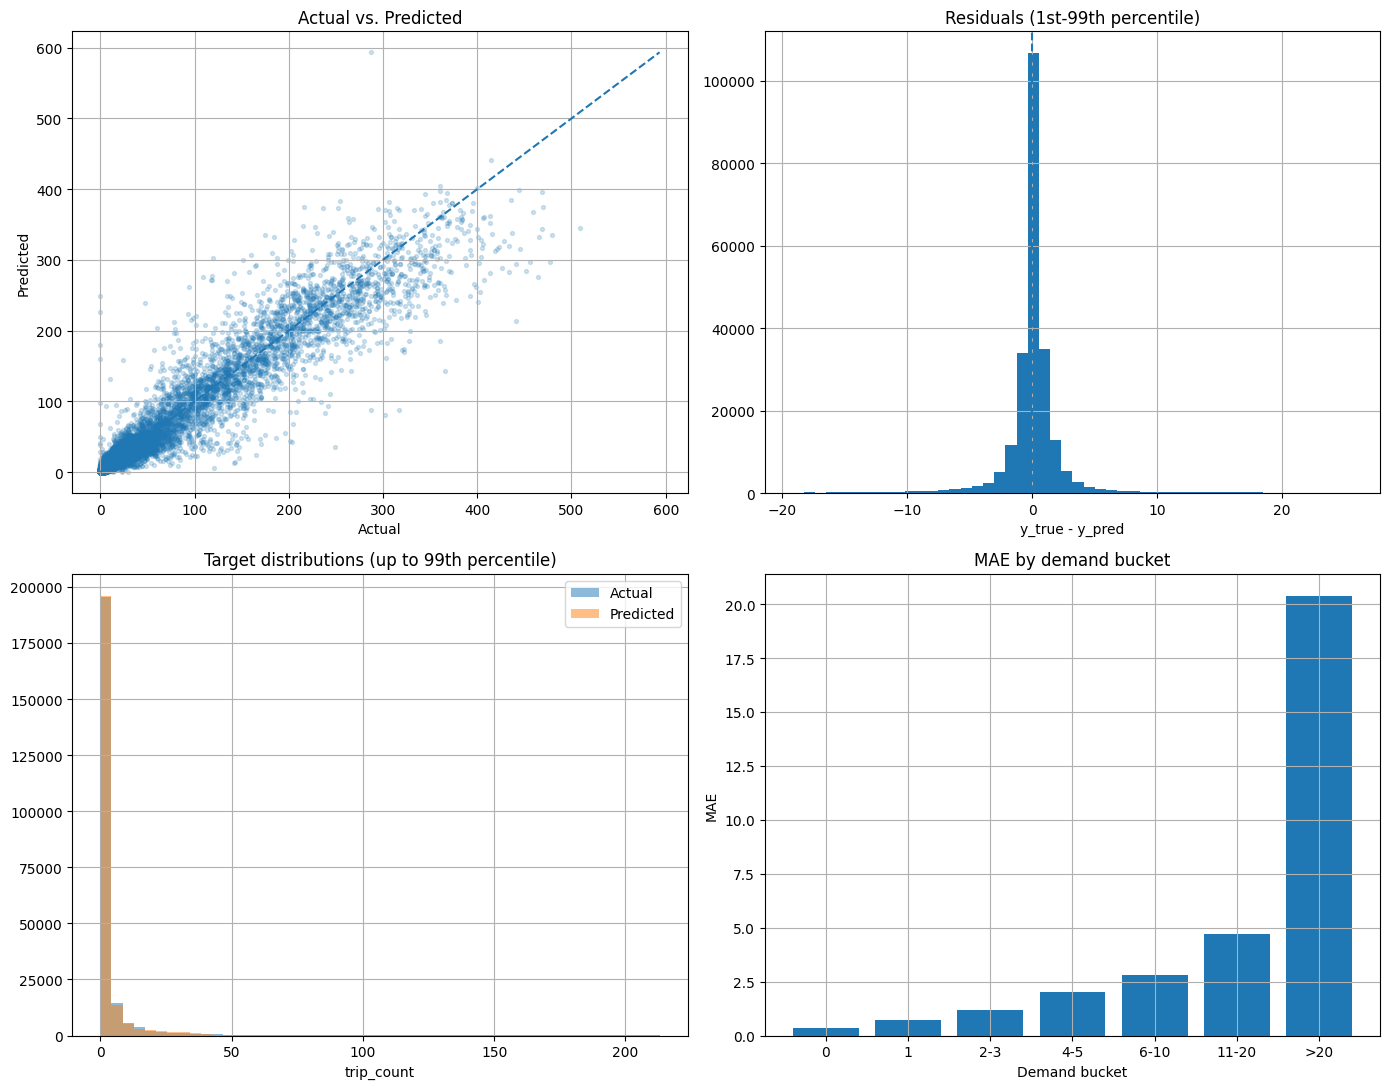

shape: (7, 5)
┌───────────────┬────────┬───────────┬────────────┬──────────────┐
│ demand_bucket ┆ n_rows ┆ mae       ┆ avg_y_true ┆ bucket_order │
│ ---           ┆ ---    ┆ ---       ┆ ---        ┆ ---          │
│ str           ┆ u32    ┆ f32       ┆ f32        ┆ i64          │
╞═══════════════╪════════╪═══════════╪════════════╪══════════════╡
│ 0             ┆ 103526 ┆ 0.333868  ┆ 0.0        ┆ 0            │
│ 1             ┆ 46118  ┆ 0.733841  ┆ 1.0        ┆ 1            │
│ 2-3           ┆ 37565  ┆ 1.204315  ┆ 2.360495   ┆ 2            │
│ 4-5           ┆ 13616  ┆ 2.004997  ┆ 4.397106   ┆ 3            │
│ 6-10          ┆ 11039  ┆ 2.804963  ┆ 7.191593   ┆ 4            │
│ 11-20         ┆ 8344   ┆ 4.695219  ┆ 13.549617  ┆ 5            │
│ >20           ┆ 15803  ┆ 20.384533 ┆ 102.870659 ┆ 6            │
└───────────────┴────────┴───────────┴────────────┴──────────────┘


In [20]:
val_eval_df = collect_predictions(
    model,
    val_loader,
    device=device,
    embedding_input=True,
)

val_metrics_df = compute_regression_metrics(val_eval_df)
print(val_metrics_df)

figure, bucket_eval_df = plot_regression_diagnostics(
    val_eval_df
)

plt.show()
print(bucket_eval_df)